<a href="https://colab.research.google.com/github/abhishekappu1902-lang/Ai-based-Heart-Attack-Prediction-System/blob/main/Ai%20Based%20Heart%20Attack%20Pred/Herat_Attack_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **PROBLEM STATEMENT**


 With HadHeartAttack as the prediction variable, the task would involve using other features in the dataset to predict whether a patient has experienced a heart attack. This could be approached as a binary classification problem, where the model learns patterns from the other variables to predict the likelihood of HadHeartAttack (0 for no, 1 for yes).


Heart disease is one of the leading causes of mortality worldwide, with heart attacks being a primary manifestation. Early detection and intervention can significantly reduce the risk and improve patient outcomes. In this project, we aim to develop a predictive model that leverages patient demographic, health, and lifestyle information to determine the likelihood of a heart attack occurrence. By analyzing this data, healthcare providers may gain insights into high-risk patients, enabling proactive measures and better allocation of medical resources.

The objective is to predict whether a patient has had a heart attack (binary outcome: HadHeartAttack) based on a range of features, including medical history, lifestyle habits, and demographic details. This model could serve as an assistive tool in clinical decision-making and help in implementing preventive healthcare strategies

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 182897 entries, 1 to 448853
Data columns (total 22 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Sex                        182897 non-null  int64  
 1   GeneralHealth              182897 non-null  int64  
 2   AgeCategory                182897 non-null  float64
 3   HadAngina                  182897 non-null  int64  
 4   HadStroke                  182897 non-null  int64  
 5   HadSkinCancer              182897 non-null  int64  
 6   HadCOPD                    182897 non-null  int64  
 7   HadKidneyDisease           182897 non-null  int64  
 8   HadArthritis               182897 non-null  int64  
 9   HadDiabetes                182897 non-null  int64  
 10  DeafOrHardOfHearing        182897 non-null  int64  
 11  BlindOrVisionDifficulty    182897 non-null  int64  
 12  DifficultyConcentrating    182897 non-null  int64  
 13  DifficultyWalking          182897 

In [ ]:
df = pd.read_csv('/content/Patients Data ( Used for Heart Disease Prediction ) (14).csv')
df.head()

,PatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1,"White only, Non-Hispanic",0,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received Tdap",0,0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",1,0,0,0,"Yes, received tetanus shot but not sure what type",0,0
3,4,Alabama,Male,Very good,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
4,5,Alabama,Female,Good,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,Never used e-cigarettes in my entire life,1,"Black only, Non-Hispanic",0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0


In [ ]:
df.isnull().sum()

,0
PatientID,0
State,0
Sex,0
GeneralHealth,0
AgeCategory,0
HeightInMeters,0
WeightInKilograms,0
BMI,0
HadHeartAttack,0
HadAngina,0


<Axes: >

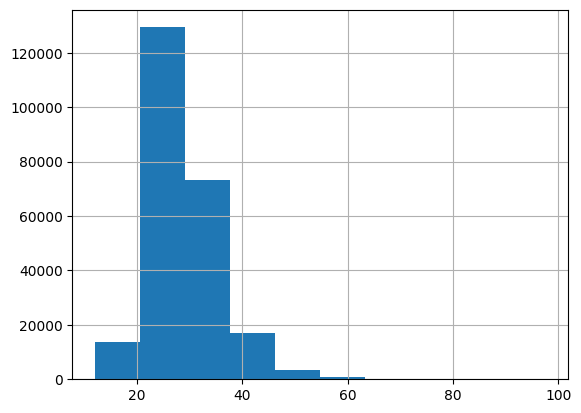

In [ ]:
df["BMI"].hist()

In [ ]:
print(df['State'].unique())

['Alabama' 'Alaska' 'Arizona' 'California' 'Arkansas' 'Connecticut'
 'Colorado' 'Delaware' 'Florida' 'Georgia' 'Hawaii' 'Idaho' 'Indiana'
 'District of Columbia' 'Kansas' 'Iowa' 'Maryland' 'Minnesota' 'Montana'
 'New Jersey' 'Nebraska' 'New York' 'Ohio' 'Oklahoma' 'Texas' 'Vermont'
 'Washington' 'Utah' 'Illinois' 'West Virginia' 'Virginia' 'Massachusetts'
 'Kentucky' 'Louisiana' 'Maine' 'Wisconsin' 'Michigan' 'Mississippi'
 'Missouri' 'Nevada' 'New Hampshire' 'New Mexico' 'South Carolina'
 'North Carolina' 'North Dakota' 'Oregon' 'Pennsylvania' 'Rhode Island'
 'South Dakota' 'Tennessee' 'Wyoming' 'Guam' 'Puerto Rico'
 'Virgin Islands']


In [ ]:
df['State'].value_counts()

,count
State,
Washington,14241
Maryland,8817
Minnesota,8712
Ohio,8700
New York,8625
Texas,7267
Florida,7124
Kansas,6000
Wisconsin,5890


In [ ]:
print(df['GeneralHealth'].unique())

['Fair' 'Very good' 'Excellent' 'Good' 'Poor']


In [ ]:
df["GeneralHealth"].replace(['Poor', 'Fair', 'Good', 'Very good', 'Excellent'],[1,2,3,4,5],inplace=True)

/tmp/ipykernel_974/3446040248.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["GeneralHealth"].replace(['Poor', 'Fair', 'Good', 'Very good', 'Excellent'],[1,2,3,4,5],inplace=True)
/tmp/ipykernel_974/3446040248.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["GeneralHealth"].replace(['P

In [ ]:
print(df['ECigaretteUsage'].unique())

['Never used e-cigarettes in my entire life' 'Not at all (right now)'
 'Use them some days' 'Use them every day']


In [ ]:
df["ECigaretteUsage"].replace(['Never used e-cigarettes in my entire life','Not at all (right now)'
,'Use them some days','Use them every day'],[0,1,2,3],inplace=True)

/tmp/ipykernel_974/2701777562.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["ECigaretteUsage"].replace(['Never used e-cigarettes in my entire life','Not at all (right now)'
/tmp/ipykernel_974/2701777562.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["ECigaretteUsage"].replace(['Neve

In [ ]:
print(df['RaceEthnicityCategory'].unique())

['White only, Non-Hispanic' 'Black only, Non-Hispanic'
 'Other race only, Non-Hispanic' 'Multiracial, Non-Hispanic' 'Hispanic']


In [ ]:
print(df['TetanusLast10Tdap'].unique())

['No, did not receive any tetanus shot in the past 10 years'
 'Yes, received Tdap' 'Yes, received tetanus shot but not sure what type'
 'Yes, received tetanus shot, but not Tdap']


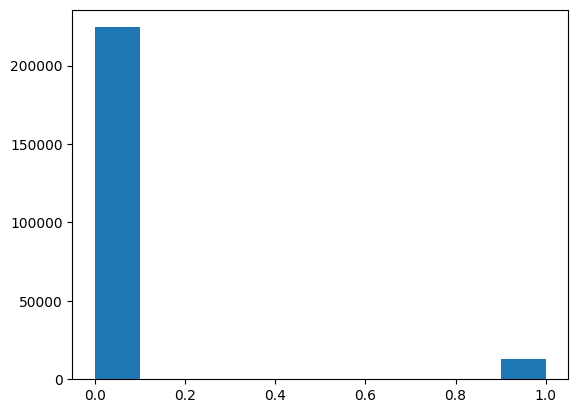

In [ ]:
plt.hist(df["HadHeartAttack"])
plt.show()

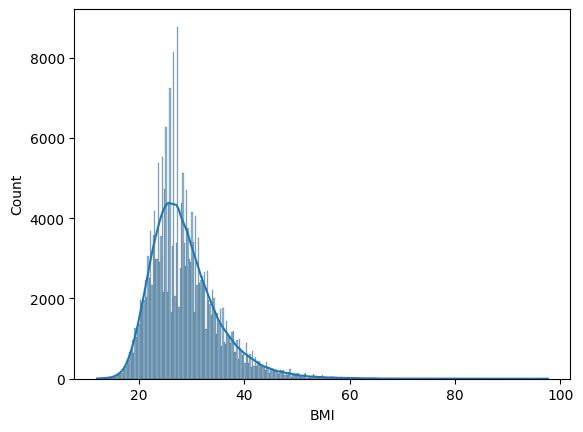

In [ ]:
sns.histplot(df['BMI'], kde=True)
plt.show()

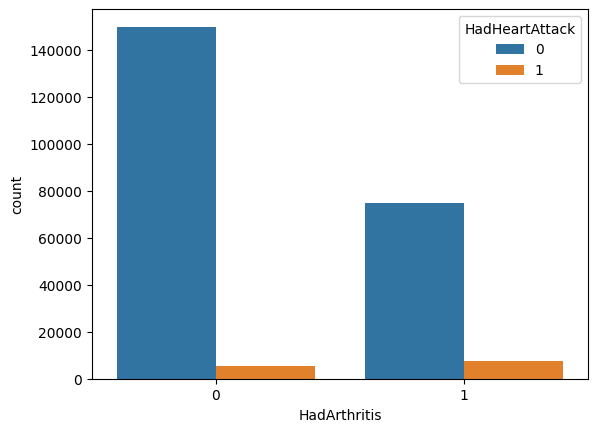

In [ ]:
sns.countplot(data=df, x='HadArthritis', hue='HadHeartAttack')
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df['State'] = le.fit_transform(df['State'])
df['GeneralHealth'] = le.fit_transform(df['GeneralHealth'])
df['ECigaretteUsage'] = le.fit_transform(df['ECigaretteUsage'])
df['RaceEthnicityCategory'] = le.fit_transform(df['RaceEthnicityCategory'])
df['TetanusLast10Tdap'] = le.fit_transform(df['TetanusLast10Tdap'])
df['Sex'] = le.fit_transform(df['Sex'])
df['HadDiabetes'] = le.fit_transform(df['HadDiabetes'])



In [ ]:
df["AgeCategory"].replace([

    "Age 18 to 24",

    "Age 25 to 29",

    "Age 30 to 34",

    "Age 35 to 39",

    "Age 40 to 44",

    "Age 45 to 49",

    "Age 50 to 54",

    "Age 55 to 59",

    "Age 60 to 64",

    "Age 65 to 69",

    "Age 70 to 74",

    "Age 75 to 79",

    "Age 80 or older"

], [

    21,    # (18+24)/2

    27,    # (25+29)/2

    32,    # (30+34)/2

    37,    # (35+39)/2

    42,    # (40+44)/2

    47,    # (45+49)/2

    52,    # (50+54)/2

    57,    # (55+59)/2

    62,    # (60+64)/2

    67,    # (65+69)/2

    72,    # (70+74)/2

    77,    # (75+79)/2

    82.5   # assumption for "80 or older"

], inplace=True)


/tmp/ipykernel_974/705331237.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["AgeCategory"].replace([
/tmp/ipykernel_974/705331237.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["AgeCategory"].replace([


In [ ]:
df["SmokerStatus"].replace([
    "Never smoked",
    "Former smoker",
    "Current smoker - now smokes some days",
    "Current smoker - now smokes every day"
],[1,2,3,4],inplace=True)

/tmp/ipykernel_974/1513632704.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["SmokerStatus"].replace([
/tmp/ipykernel_974/1513632704.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["SmokerStatus"].replace([


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   PatientID                  237630 non-null  int64  
 1   State                      237630 non-null  int64  
 2   Sex                        237630 non-null  int64  
 3   GeneralHealth              237630 non-null  int64  
 4   AgeCategory                237630 non-null  float64
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import pandas as pd
X = df.drop("HadHeartAttack", axis=1)
y = df["HadHeartAttack"]


smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(
    X,
    y
)

df_smote = pd.concat(
    [X_smote, y_smote.rename("HadHeartAttack")],
    axis=1
)


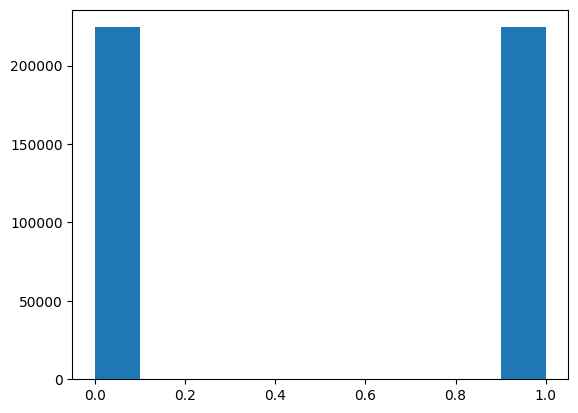

In [ ]:
plt.hist(df_smote["HadHeartAttack"])
plt.show()

In [ ]:
df=df_smote

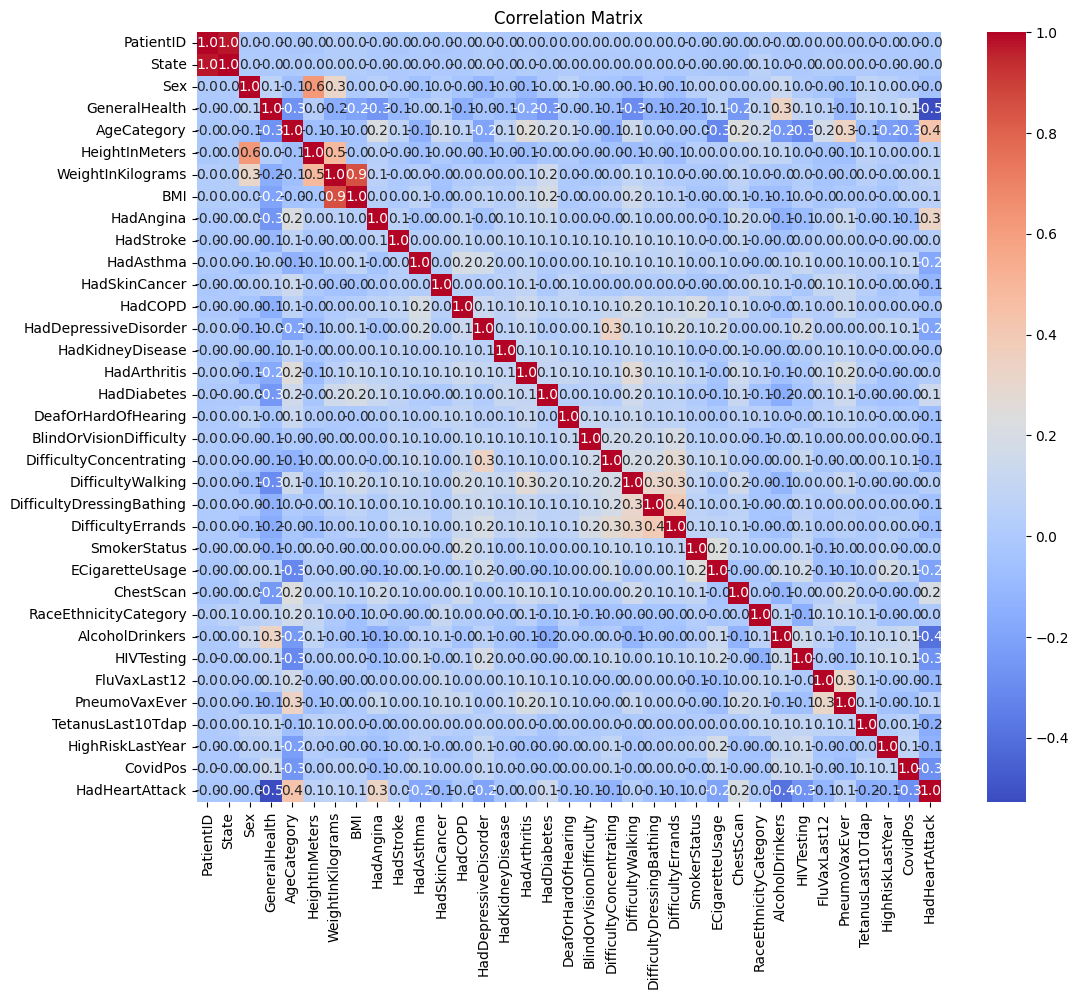

In [ ]:
corr_matrix = df.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix,annot=True, fmt='0.01f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()



In [ ]:
df.drop(["State","WeightInKilograms"],axis=1,inplace=True)

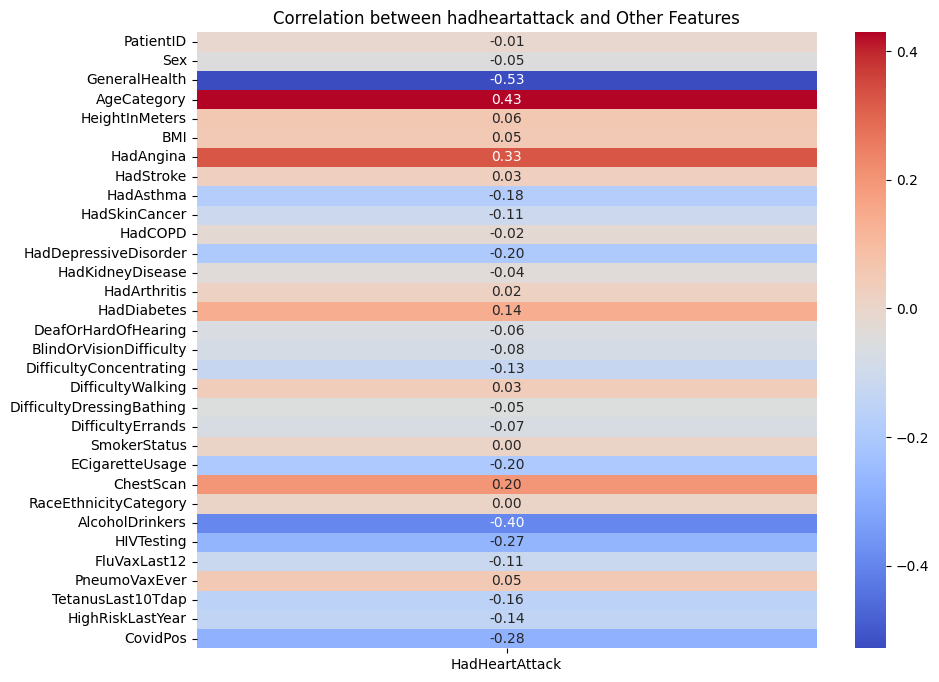

In [ ]:
HadHeartAttack_corr = df.corr()['HadHeartAttack']
plt.figure(figsize=(10,8))
HadHeartAttack_corr = HadHeartAttack_corr.drop('HadHeartAttack')
sns.heatmap(HadHeartAttack_corr.to_frame(), annot=True, fmt='.2f', cmap='coolwarm',
            cbar=True, annot_kws={'size': 10})
plt.title('Correlation between hadheartattack and Other Features')
plt.show()

In [ ]:

drop_cols = [
    "PatientID",
    "HeightInMeters",
    "BMI",
    "HadAsthma",
    "HadDepressiveDisorder",
    "ECigaretteUsage",
    "RaceEthnicityCategory",
    "HIVTesting",
    "TetanusLast10Tdap",
    "HighRiskLastYear",
    "CovidPos"
]
df.drop(drop_cols,axis=1,inplace=True)



In [ ]:
df

,Sex,GeneralHealth,AgeCategory,HadAngina,HadStroke,HadSkinCancer,HadCOPD,HadKidneyDisease,HadArthritis,HadDiabetes,...,DifficultyConcentrating,DifficultyWalking,DifficultyDressingBathing,DifficultyErrands,SmokerStatus,ChestScan,AlcoholDrinkers,FluVaxLast12,PneumoVaxEver,HadHeartAttack
0,0,1,77.000000,1,0,1,0,0,1,2,...,0,1,0,0,2,1,0,0,1,0
1,0,3,67.000000,0,0,0,0,0,1,0,...,0,0,0,0,2,0,0,1,1,0
2,1,4,62.000000,0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
3,1,3,72.000000,0,0,0,0,0,1,2,...,0,0,0,0,2,0,0,1,1,0
4,0,2,52.000000,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
448853,0,1,62.695735,0,0,0,0,0,0,0,...,0,0,0,0,2,1,0,0,0,1
448854,0,0,62.000000,1,0,0,0,0,0,1,...,0,0,0,0,4,0,0,0,0,1
448855,0,1,66.772860,0,0,1,0,0,0,1,...,0,0,0,0,2,1,1,0,0,1
448856,0,1,56.480848,1,1,0,0,0,1,0,...,0,0,0,0,1,1,0,1,1,1


<Axes: >

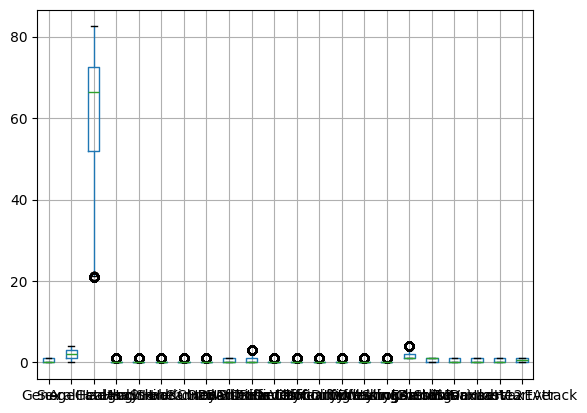

In [ ]:
df.boxplot()

In [ ]:
def remove_outliers_iqr(df, exclude_column):
    for col in df.columns:
        if col == exclude_column:
            continue
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

df_cleaned = remove_outliers_iqr(df, exclude_column='HadHeartAttack')
df=df_cleaned

In [ ]:
df.shape

(182897, 22)

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
features = [
    'Sex',
    'GeneralHealth',
    'AgeCategory',
    'HadAngina',
    'HadStroke',
    'HadSkinCancer',
    'HadCOPD',
    'HadKidneyDisease',
    'HadArthritis',
    'BlindOrVisionDifficulty',
    'DifficultyConcentrating',
    'DifficultyWalking',
    'DifficultyDressingBathing',
    'DifficultyErrands',
    'SmokerStatus',
    'ChestScan',
    'AlcoholDrinkers',
    'FluVaxLast12',
    'PneumoVaxEver'
]
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[features])

scaled_df = pd.DataFrame(scaled_data, columns=features)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd
X = df[[
    "GeneralHealth",
    "AgeCategory",
    "HadAngina",
    "HadStroke",
    "HadSkinCancer",
    "HadCOPD",
    "HadKidneyDisease",
    "HadArthritis",
    "HadDiabetes",
    "DeafOrHardOfHearing",
    "BlindOrVisionDifficulty",
    "DifficultyConcentrating",
    "DifficultyWalking",
    "DifficultyDressingBathing",
    "DifficultyErrands",
    "SmokerStatus",
    "ChestScan",
    "AlcoholDrinkers",
    "FluVaxLast12",
    "PneumoVaxEver"
]]
y = df['HadHeartAttack']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.86


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
X = df[[
    "GeneralHealth",
    "AgeCategory",
    "HadAngina",
    "HadStroke",
    "HadSkinCancer",
    "HadCOPD",
    "HadKidneyDisease",
    "HadArthritis",
    "HadDiabetes",
    "DeafOrHardOfHearing",
    "BlindOrVisionDifficulty",
    "DifficultyConcentrating",
    "DifficultyWalking",
    "DifficultyDressingBathing",
    "DifficultyErrands",
    "SmokerStatus",
    "ChestScan",
    "AlcoholDrinkers",
    "FluVaxLast12",
    "PneumoVaxEver"
]]
y = df['HadHeartAttack']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.95


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
X = df[[
    "GeneralHealth",
    "AgeCategory",
    "HadAngina",
    "HadStroke",
    "HadSkinCancer",
    "HadCOPD",
    "HadKidneyDisease",
    "HadArthritis",
    "HadDiabetes",
    "DeafOrHardOfHearing",
    "BlindOrVisionDifficulty",
    "DifficultyConcentrating",
    "DifficultyWalking",
    "DifficultyDressingBathing",
    "DifficultyErrands",
    "SmokerStatus",
    "ChestScan",
    "AlcoholDrinkers",
    "FluVaxLast12",
    "PneumoVaxEver"
]]
y = df['HadHeartAttack']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
model = AdaBoostClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.88


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
X = df[[
    "GeneralHealth",
    "AgeCategory",
    "HadAngina",
    "HadStroke",
    "HadSkinCancer",
    "HadCOPD",
    "HadKidneyDisease",
    "HadArthritis",
    "HadDiabetes",
    "DeafOrHardOfHearing",
    "BlindOrVisionDifficulty",
    "DifficultyConcentrating",
    "DifficultyWalking",
    "DifficultyDressingBathing",
    "DifficultyErrands",
    "SmokerStatus",
    "ChestScan",
    "AlcoholDrinkers",
    "FluVaxLast12",
    "PneumoVaxEver"
]]
y = df['HadHeartAttack']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.94


In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
X = df[[
    "GeneralHealth",
    "AgeCategory",
    "HadAngina",
    "HadStroke",
    "HadSkinCancer",
    "HadCOPD",
    "HadKidneyDisease",
    "HadArthritis",
    "HadDiabetes",
    "DeafOrHardOfHearing",
    "BlindOrVisionDifficulty",
    "DifficultyConcentrating",
    "DifficultyWalking",
    "DifficultyDressingBathing",
    "DifficultyErrands",
    "SmokerStatus",
    "ChestScan",
    "AlcoholDrinkers",
    "FluVaxLast12",
    "PneumoVaxEver"
]]
y = df['HadHeartAttack']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
model = XGBClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.94


# CONCLUSION
This project focused on predicting the occurrence of heart attacks using a healthcare dataset containing demographic, lifestyle, and medical-history variables. The dataset underwent preprocessing steps such as handling categorical variables through encoding, feature selection, and balancing the target classes using the SMOTE technique. Exploratory data analysis and correlation analysis were also performed to identify important features and understand relationships among variables.

To evaluate the predictive performance, multiple machine learning models including Decision Tree, Random Forest, AdaBoost, and XGBoost were implemented and compared. Each model was trained and validated using appropriate evaluation techniques to ensure reliable results. Among all the models tested, the Decision Tree classifier achieved the highest accuracy and demonstrated the best overall performance for this dataset. Therefore, the Decision Tree model was selected as the final model for heart attack prediction, indicating its effectiveness in capturing the patterns and relationships present in the healthcare data.





